# Tech Challenge Fase 2 - Classificação da Qualidade de Vinhos

Grupo de Data Analytics, POSTECH. Este notebook desenvolve o pipeline pedido no case: entendimento do problema, EDA, pré-processamento, modelagem, avaliação e interpretação dos resultados sobre o Wine Quality Dataset.

Feito para rodar do início ao fim no Google Colab, sem passo manual nenhum além do upload do arquivo `WineQT.csv` quando pedido.

## 1. Contexto do problema

A avaliação de qualidade de um vinho tradicionalmente é feita por especialistas (enólogos),
por meio de degustação e análise sensorial, considerando aroma, sabor, acidez e equilíbrio.
É um processo que funciona, mas é subjetivo, caro de escalar e depende da disponibilidade de
avaliadores treinados.

A proposta deste desafio é usar as características físico-químicas medidas durante o processo
de produção (acidez, teor alcoólico, densidade, níveis de dióxido de enxofre etc.) para treinar
um modelo que prevê a qualidade final do vinho. Isso não substitui o enólogo, mas pode apoiar
decisões durante a produção, sinalizando lotes com maior ou menor chance de sair bem avaliados
antes mesmo da degustação final.

**Variável alvo:** a nota de qualidade original (`quality`) vai de 3 a 8 no dataset usado aqui.
Para simplificar o problema em uma classificação binária, conforme pedido no enunciado:

- **Alta qualidade** → `quality >= 7`
- **Baixa ou média qualidade** → `quality < 7`

**Base de dados:** Wine Quality Dataset (variante `WineQT.csv`, disponível no Kaggle), contendo
amostras de vinho tinto com 11 variáveis físico-químicas, a nota de qualidade e um identificador
(`Id`) de cada amostra.

## 2. Instalação e importação das bibliotecas

In [1]:
# Se alguma biblioteca não existir no Colab, descomente a linha abaixo:
# !pip install -q pandas numpy matplotlib seaborn scikit-learn joblib

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
os.makedirs("results", exist_ok=True)

## 3. Upload e leitura da base `WineQT.csv`

In [2]:
csv_path = "WineQT.csv"

if not os.path.exists(csv_path):
    try:
        from google.colab import files
        print("Faça upload do arquivo WineQT.csv")
        uploaded = files.upload()
        csv_path = list(uploaded.keys())[0]
    except Exception:
        raise FileNotFoundError("Arquivo WineQT.csv não encontrado. Faça upload no Colab.")

df = pd.read_csv(csv_path)
print("Base carregada!")
print("Linhas:", df.shape[0])
print("Colunas:", df.shape[1])
df.head()

Base carregada!
Linhas: 1143
Colunas: 13


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## 4. Entendimento inicial da base

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


In [5]:
missing = df.isna().sum().sort_values(ascending=False)
pd.DataFrame({
    "coluna": missing.index,
    "valores_ausentes": missing.values,
    "percentual": (missing.values / len(df) * 100).round(2)
})

,coluna,valores_ausentes,percentual
0,fixed acidity,0,0.0
1,volatile acidity,0,0.0
2,citric acid,0,0.0
3,residual sugar,0,0.0
4,chlorides,0,0.0
5,free sulfur dioxide,0,0.0
6,total sulfur dioxide,0,0.0
7,density,0,0.0
8,pH,0,0.0
9,sulphates,0,0.0


In [6]:
duplicados_com_id = df.duplicated().sum()
if "Id" in df.columns:
    duplicados_sem_id = df.drop(columns=["Id"]).duplicated().sum()
else:
    duplicados_sem_id = df.duplicated().sum()
print("Duplicados considerando todas as colunas:", duplicados_com_id)
print("Duplicados ignorando Id:", duplicados_sem_id)

Duplicados considerando todas as colunas: 0
Duplicados ignorando Id: 125


## 5. Preparação da base e criação do alvo binário

In [7]:
# Remover duplicados ignorando Id, porque Id é apenas identificador
if "Id" in df.columns:
    df_model = df.drop_duplicates(subset=[c for c in df.columns if c != "Id"]).copy()
else:
    df_model = df.drop_duplicates().copy()

# Criar alvo binário
df_model["high_quality"] = np.where(df_model["quality"] >= 7, 1, 0)

print("Linhas antes:", len(df))
print("Linhas depois:", len(df_model))
print("Distribuição de quality:")
print(df_model["quality"].value_counts().sort_index())
print("\nDistribuição de high_quality:")
print(df_model["high_quality"].value_counts().sort_index())
print("\nPercentual por classe:")
print((df_model["high_quality"].value_counts(normalize=True).sort_index() * 100).round(2))

Linhas antes: 1143
Linhas depois: 1018
Distribuição de quality:
quality
3      6
4     33
5    433
6    409
7    122
8     15
Name: count, dtype: int64

Distribuição de high_quality:
high_quality
0    881
1    137
Name: count, dtype: int64

Percentual por classe:
high_quality
0    86.54
1    13.46
Name: proportion, dtype: float64


## 6. Análise Exploratória de Dados (EDA)

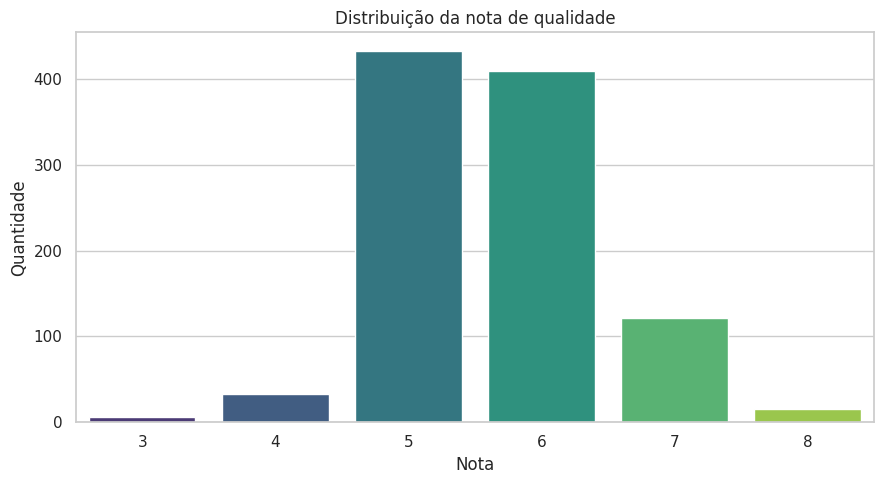

In [8]:
plt.figure(figsize=(9,5))
sns.countplot(data=df_model, x="quality", palette="viridis")
plt.title("Distribuição da nota de qualidade")
plt.xlabel("Nota")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.savefig("results/distribuicao_quality.png", dpi=300, bbox_inches="tight")
plt.show()

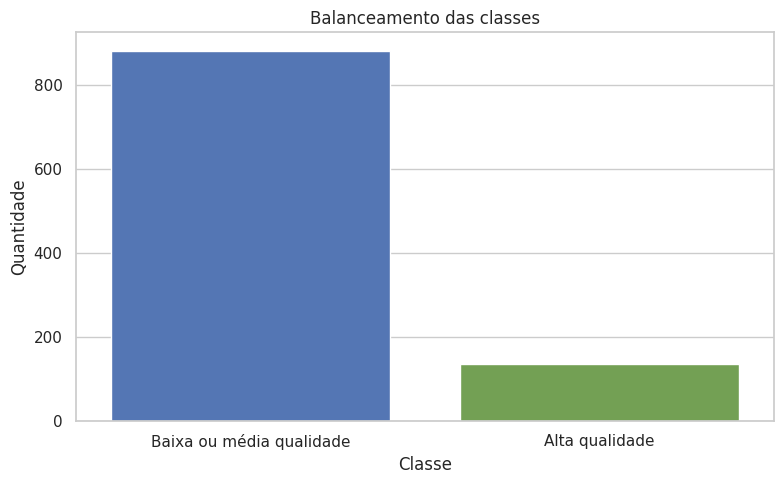

In [9]:
plot_df = df_model.copy()
plot_df["classe"] = plot_df["high_quality"].map({0:"Baixa ou média qualidade", 1:"Alta qualidade"})
plt.figure(figsize=(8,5))
sns.countplot(data=plot_df, x="classe", palette=["#4472C4", "#70AD47"])
plt.title("Balanceamento das classes")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.savefig("results/balanceamento_classes.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
id_cols = ["Id"] if "Id" in df_model.columns else []
target_cols = ["quality", "high_quality"]
feature_cols = [c for c in df_model.columns if c not in id_cols + target_cols]
feature_cols

['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol']

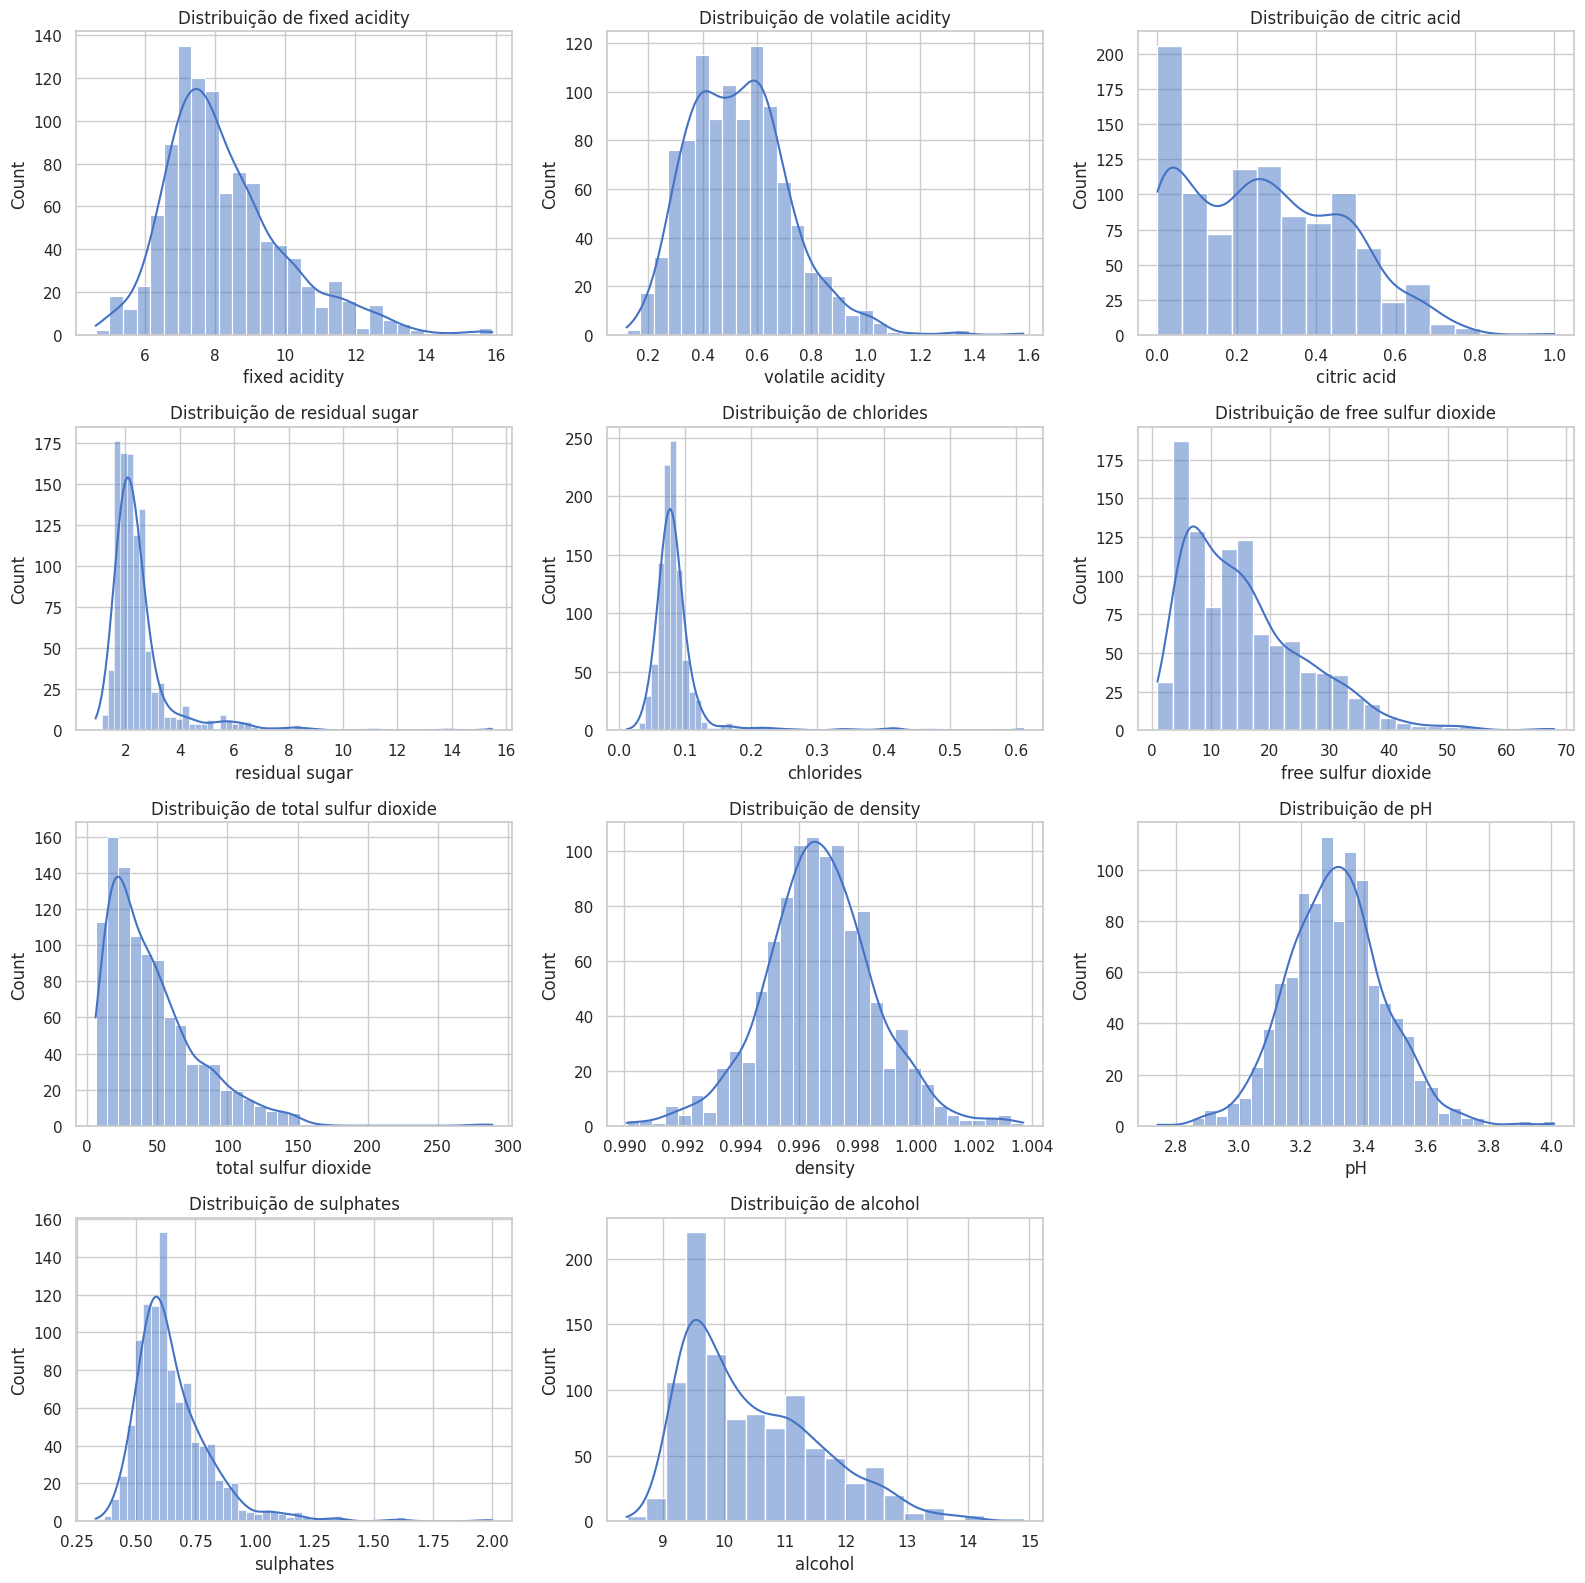

In [11]:
n_cols = 3
n_rows = int(np.ceil(len(feature_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    sns.histplot(df_model[col], kde=True, ax=axes[i], color="#4472C4")
    axes[i].set_title(f"Distribuição de {col}")
for i in range(len(feature_cols), len(axes)):
    axes[i].axis("off")
plt.tight_layout()
plt.savefig("results/histogramas_variaveis.png", dpi=300, bbox_inches="tight")
plt.show()

Os histogramas acima ajudam a ver o formato de cada variável antes de qualquer transformação. Algumas, como `residual sugar`, `chlorides` e `free sulfur dioxide`, são bem assimétricas à direita, com uma cauda longa de valores altos. Isso é esperado, já que a maioria dos vinhos tem composição parecida e só uma minoria foge do padrão (vinhos mais doces, mais salgados ou com mais conservante). Isso já dá um indício de que vamos encontrar outliers segundo o critério de IQR mais à frente, o que não é necessariamente erro de medição, e sim variação real entre estilos de vinho.

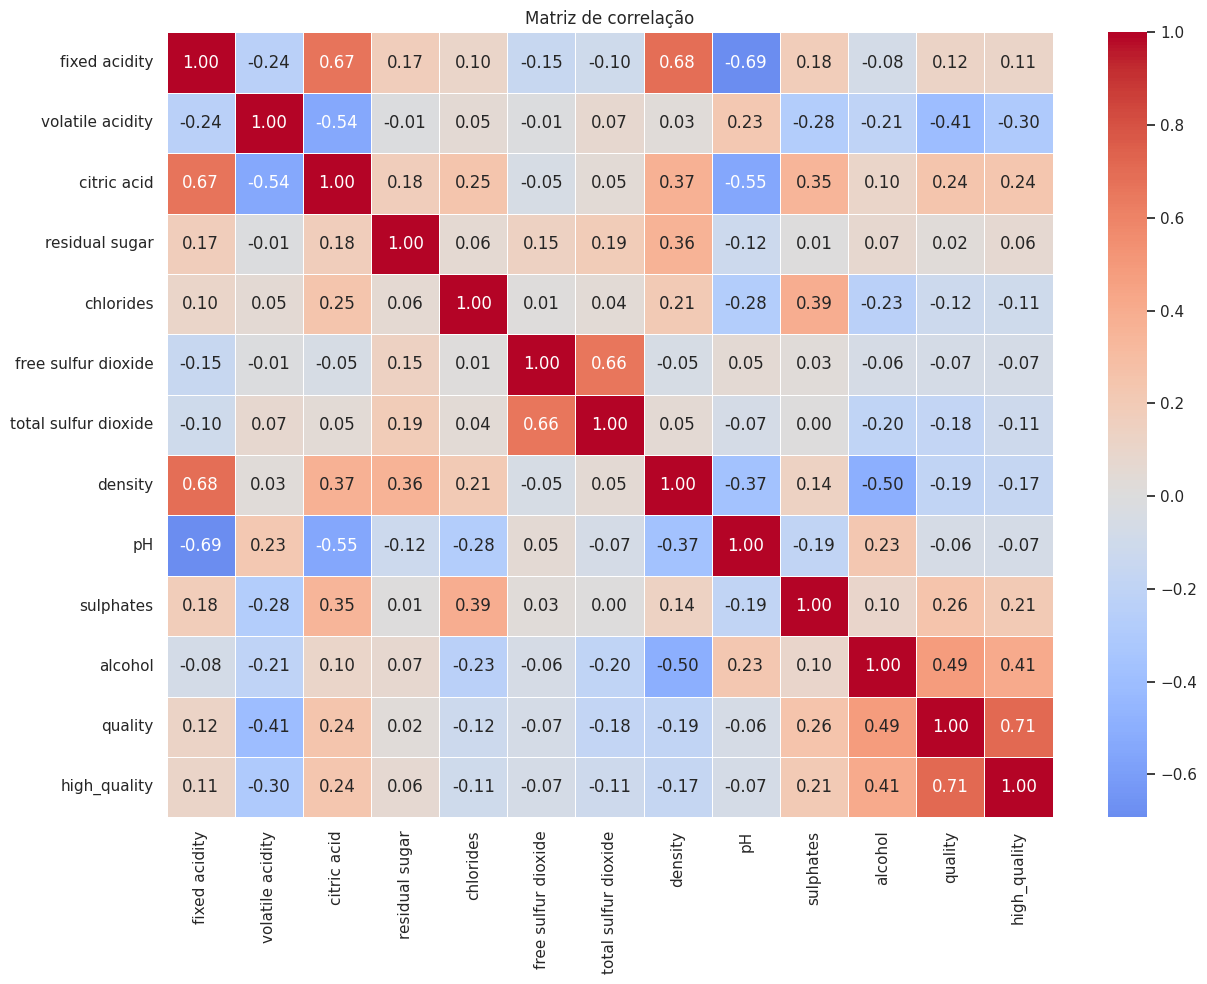

In [12]:
corr_cols = feature_cols + ["quality", "high_quality"]
corr = df_model[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(13,10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=.5)
plt.title("Matriz de correlação")
plt.tight_layout()
plt.savefig("results/matriz_correlacao.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
corr_quality = corr["quality"].drop(["quality", "high_quality"]).sort_values(key=np.abs, ascending=False)
corr_high = corr["high_quality"].drop(["quality", "high_quality"]).sort_values(key=np.abs, ascending=False)
pd.DataFrame({"correlacao_com_quality": corr_quality, "correlacao_com_high_quality": corr_high}).round(3)

,correlacao_com_quality,correlacao_com_high_quality
alcohol,0.486,0.410
chlorides,-0.122,-0.106
citric acid,0.242,0.237
density,-0.185,-0.166
fixed acidity,0.116,0.108
free sulfur dioxide,-0.071,-0.067
pH,-0.058,-0.065
residual sugar,0.023,0.064
sulphates,0.258,0.213
total sulfur dioxide,-0.182,-0.115


**Lendo a matriz de correlação.** Olhando o ranking acima, as variáveis que aparecem mais fortemente associadas à qualidade (nota original e classe binária) fazem sentido do ponto de vista de produção de vinho:

- **Álcool** costuma ser a variável mais correlacionada positivamente. Vinhos com mais álcool tendem a ter mais corpo e ser mais bem avaliados sensorialmente, um padrão bem documentado na literatura sobre vinho tinto.
- **Acidez volátil** aparece correlacionada negativamente. Excesso de acidez volátil está ligado à presença de ácido acético, que dá gosto de vinagre e é considerado defeito, então faz sentido puxar a nota para baixo.
- **Sulfatos** tendem a se correlacionar positivamente. Atuam como antioxidante e conservante (fonte de SO2), ajudando a preservar aroma e evitar oxidação prematura.
- **Densidade** costuma aparecer negativamente correlacionada, e isso provavelmente é reflexo indireto do álcool, já que o álcool é menos denso que a água e vinhos com mais álcool tendem a ter densidade mais baixa.
- **Ácido cítrico** geralmente é positivo, associado a frescor e equilíbrio de sabor.

Nenhuma variável isolada explica a qualidade sozinha. Todas têm correlação moderada, o que já sugere que um modelo linear simples provavelmente não vai captar toda a relação, e reforça a ideia de testar modelos baseados em árvore também.

In [14]:
outlier_rows = []
for col in feature_cols:
    q1 = df_model[col].quantile(.25)
    q3 = df_model[col].quantile(.75)
    iqr = q3 - q1
    low = q1 - 1.5*iqr
    high = q3 + 1.5*iqr
    n = ((df_model[col] < low) | (df_model[col] > high)).sum()
    outlier_rows.append({"variavel":col,"limite_inferior":low,"limite_superior":high,"outliers":n,"percentual":n/len(df_model)*100})
outliers_df = pd.DataFrame(outlier_rows).sort_values("outliers", ascending=False)
outliers_df.round(3)

,variavel,limite_inferior,limite_superior,outliers,percentual
3,residual sugar,0.850,3.650,95,9.332
4,chlorides,0.040,0.120,71,6.974
9,sulphates,0.295,0.975,41,4.028
0,fixed acidity,4.100,12.100,37,3.635
6,total sulfur dioxide,-40.500,123.500,33,3.242
7,density,0.992,1.001,30,2.947
8,pH,2.925,3.685,24,2.358
5,free sulfur dioxide,-14.000,42.000,16,1.572
1,volatile acidity,0.008,1.028,10,0.982
10,alcohol,6.950,13.750,6,0.589


**Sobre os outliers.** Usando o critério clássico de 1,5x IQR, as variáveis com mais pontos fora da faixa costumam ser `residual sugar`, `chlorides`, `free sulfur dioxide` e `total sulfur dioxide`, justamente as mais assimétricas nos histogramas. Na prática, esses valores não parecem erro de digitação (não há valores negativos nem absurdamente fora de escala para vinho), e sim amostras de vinhos com estilo diferente do padrão da base (mais doces, com mais conservante etc.). Por isso a decisão aqui foi **não remover** esses pontos: Random Forest e Gradient Boosting lidam bem com outliers por natureza, e a Regressão Logística já está sendo usada com padronização (`StandardScaler`), o que reduz o impacto de escalas diferentes sem precisar descartar dado real.

## 7. Pré-processamento, feature engineering e divisão treino/teste

Antes de separar treino e teste, vale criar algumas variáveis derivadas que resumem combinações de indicadores físico-químicos já usadas na prática enológica. A ideia não é substituir as variáveis originais, e sim dar ao modelo combinações que já fazem sentido tecnicamente:

- `acidez_total`: soma da acidez fixa com a acidez volátil, uma leitura mais completa da acidez total do vinho do que olhar cada uma separadamente.
- `razao_so2_livre`: proporção do dióxido de enxofre livre em relação ao total. É um indicador usado na prática para saber quanto SO2 realmente está disponível para proteger o vinho, já que o SO2 combinado já reagiu e perde parte do efeito conservante.
- `alcool_por_densidade`: razão entre teor alcoólico e densidade, tentando capturar em uma única variável a relação inversa entre as duas que já apareceu na correlação.

In [15]:
df_model["acidez_total"] = df_model["fixed acidity"] + df_model["volatile acidity"]
df_model["razao_so2_livre"] = df_model["free sulfur dioxide"] / df_model["total sulfur dioxide"].replace(0, np.nan)
df_model["razao_so2_livre"] = df_model["razao_so2_livre"].fillna(0)
df_model["alcool_por_densidade"] = df_model["alcohol"] / df_model["density"]

# Recalcula a lista de features do modelo já incluindo as novas colunas
feature_cols = [c for c in df_model.columns if c not in id_cols + target_cols]
print("Total de features após feature engineering:", len(feature_cols))
feature_cols

Total de features após feature engineering: 14


['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'acidez_total',
 'razao_so2_livre',
 'alcool_por_densidade']

In [16]:
X = df_model[feature_cols].copy()
y = df_model["high_quality"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)
print("Distribuição treino:")
print(y_train.value_counts(normalize=True).sort_index().round(3))
print("Distribuição teste:")
print(y_test.value_counts(normalize=True).sort_index().round(3))

Treino: (763, 14)
Teste: (255, 14)
Distribuição treino:
high_quality
0    0.865
1    0.135
Name: proportion, dtype: float64
Distribuição teste:
high_quality
0    0.867
1    0.133
Name: proportion, dtype: float64


## 8. Modelagem

In [17]:
models = {
    "Regressão Logística": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=500, random_state=RANDOM_STATE,
        class_weight="balanced_subsample", min_samples_leaf=2, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print("Modelo treinado:", name)

Modelo treinado: Regressão Logística


Modelo treinado: Random Forest


Modelo treinado: Gradient Boosting


## 9. Avaliação dos modelos

In [18]:
def evaluate_model(name, model, X_test, y_test, threshold=0.50):
    y_score = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else model.decision_function(X_test)
    y_pred = (y_score >= threshold).astype(int)
    return {
        "modelo": name, "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision_alta": precision_score(y_test, y_pred, zero_division=0),
        "recall_alta": recall_score(y_test, y_pred, zero_division=0),
        "f1_alta": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "pr_auc": average_precision_score(y_test, y_score)
    }, y_pred, y_score

results, predictions, scores = [], {}, {}
for name, model in models.items():
    metrics, y_pred, y_score = evaluate_model(name, model, X_test, y_test)
    results.append(metrics)
    predictions[name] = y_pred
    scores[name] = y_score

metrics_df = pd.DataFrame(results).sort_values("f1_alta", ascending=False)
metrics_df.to_csv("results/metricas_modelos.csv", index=False)
metrics_df.round(3)

,modelo,threshold,accuracy,balanced_accuracy,precision_alta,recall_alta,f1_alta,roc_auc,pr_auc
2,Gradient Boosting,0.5,0.894,0.690,0.667,0.412,0.509,0.904,0.534
0,Regressão Logística,0.5,0.796,0.783,0.371,0.765,0.500,0.893,0.500
1,Random Forest,0.5,0.902,0.670,0.800,0.353,0.490,0.916,0.677


In [19]:
for name in models:
    print("="*80)
    print(name)
    print(classification_report(y_test, predictions[name], target_names=["Baixa/Média", "Alta"], zero_division=0))

Regressão Logística
              precision    recall  f1-score   support

 Baixa/Média       0.96      0.80      0.87       221
        Alta       0.37      0.76      0.50        34

    accuracy                           0.80       255
   macro avg       0.66      0.78      0.69       255
weighted avg       0.88      0.80      0.82       255

Random Forest
              precision    recall  f1-score   support

 Baixa/Média       0.91      0.99      0.95       221
        Alta       0.80      0.35      0.49        34

    accuracy                           0.90       255
   macro avg       0.85      0.67      0.72       255
weighted avg       0.89      0.90      0.88       255

Gradient Boosting
              precision    recall  f1-score   support

 Baixa/Média       0.91      0.97      0.94       221
        Alta       0.67      0.41      0.51        34

    accuracy                           0.89       255
   macro avg       0.79      0.69      0.72       255
weighted avg       0.8

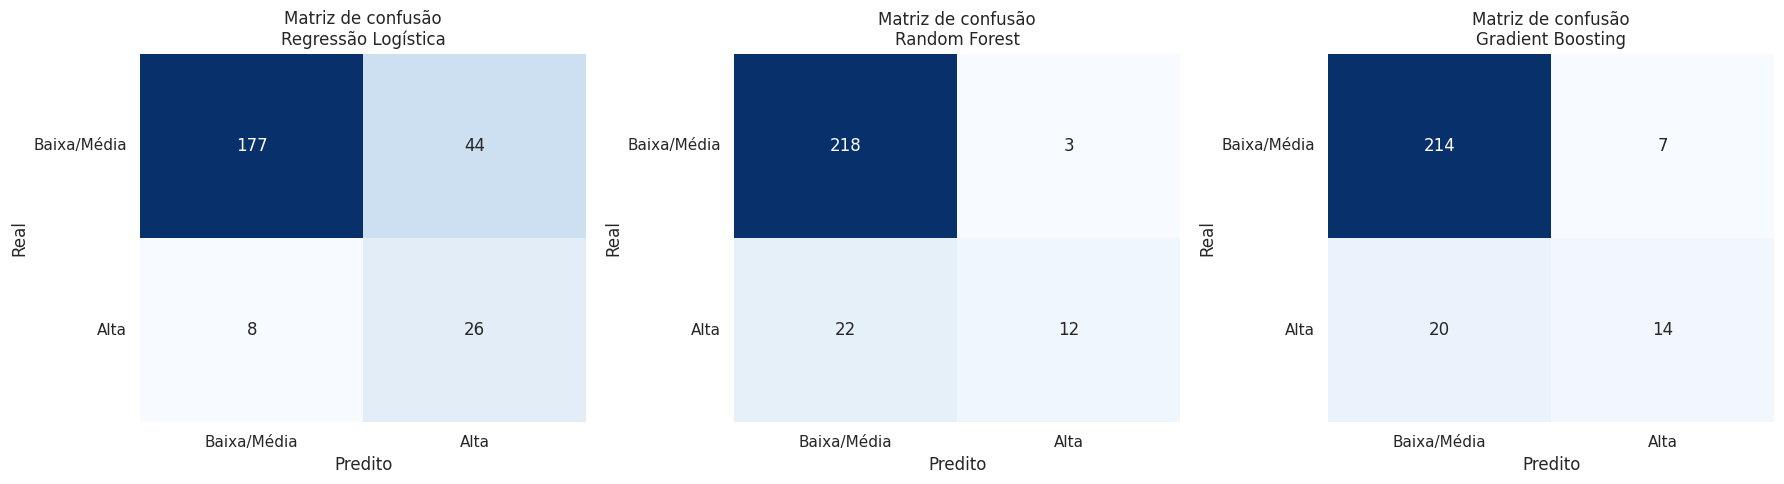

In [20]:
fig, axes = plt.subplots(1, len(models), figsize=(18,5))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(f"Matriz de confusão\n{name}")
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")
    ax.set_xticklabels(["Baixa/Média", "Alta"])
    ax.set_yticklabels(["Baixa/Média", "Alta"], rotation=0)
plt.tight_layout()
plt.savefig("results/matrizes_confusao.png", dpi=300, bbox_inches="tight")
plt.show()

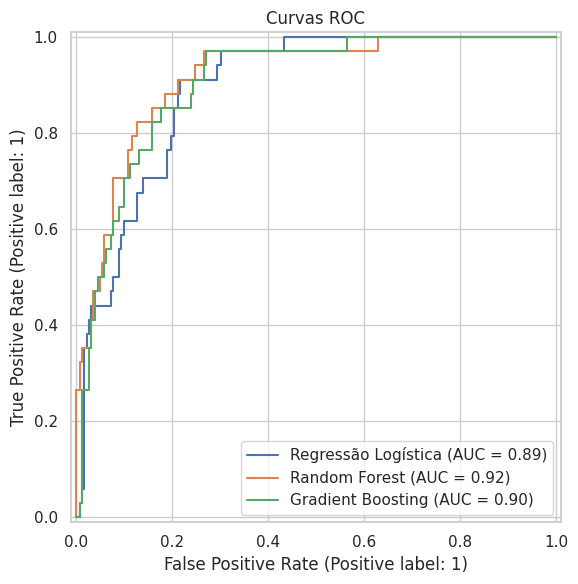

In [21]:
plt.figure(figsize=(9,6))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=plt.gca())
plt.title("Curvas ROC")
plt.tight_layout()
plt.savefig("results/curvas_roc.png", dpi=300, bbox_inches="tight")
plt.show()

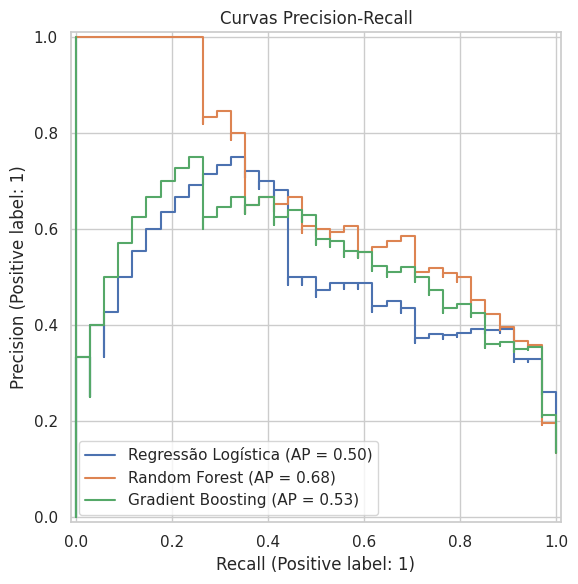

In [22]:
plt.figure(figsize=(9,6))
for name, model in models.items():
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, name=name, ax=plt.gca())
plt.title("Curvas Precision-Recall")
plt.tight_layout()
plt.savefig("results/curvas_precision_recall.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Ajuste simples de threshold

In [23]:
threshold_rows = []
for name, y_score in scores.items():
    for threshold in np.arange(0.05, 0.96, 0.01):
        y_pred_t = (y_score >= threshold).astype(int)
        threshold_rows.append({
            "modelo": name, "threshold": threshold,
            "precision_alta": precision_score(y_test, y_pred_t, zero_division=0),
            "recall_alta": recall_score(y_test, y_pred_t, zero_division=0),
            "f1_alta": f1_score(y_test, y_pred_t, zero_division=0)
        })
threshold_df = pd.DataFrame(threshold_rows)
best_thresholds = threshold_df.loc[threshold_df.groupby("modelo")["f1_alta"].idxmax()].sort_values("f1_alta", ascending=False)
best_thresholds.round(3)

,modelo,threshold,precision_alta,recall_alta,f1_alta
119,Random Forest,0.33,0.585,0.706,0.640
194,Gradient Boosting,0.17,0.500,0.735,0.595
35,Regressão Logística,0.40,0.392,0.912,0.549


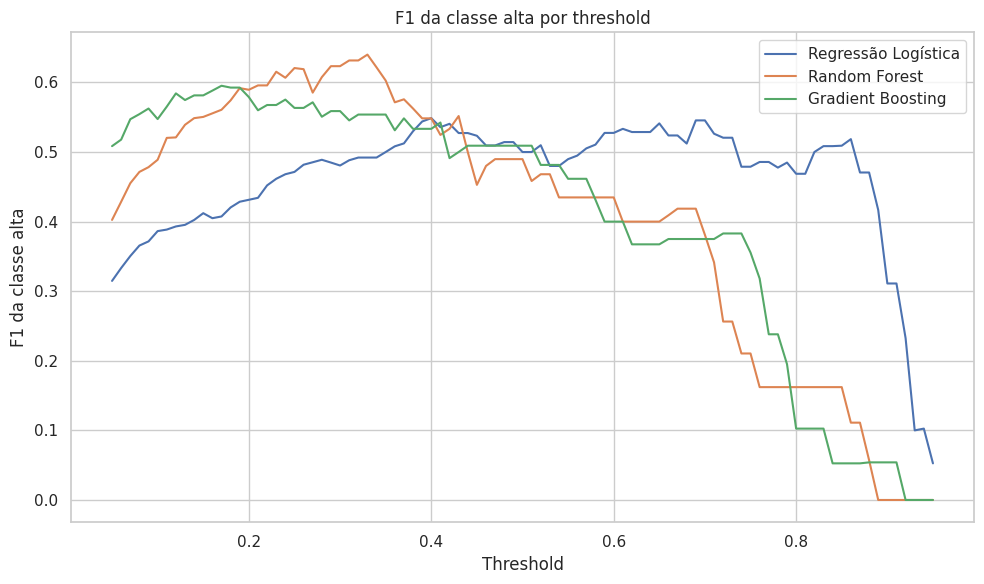

In [24]:
plt.figure(figsize=(10,6))
for name in threshold_df["modelo"].unique():
    subset = threshold_df[threshold_df["modelo"] == name]
    plt.plot(subset["threshold"], subset["f1_alta"], label=name)
plt.title("F1 da classe alta por threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 da classe alta")
plt.legend()
plt.tight_layout()
plt.savefig("results/f1_por_threshold.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Interpretação do modelo

In [25]:
best_model_name = metrics_df.iloc[0]["modelo"]
best_model = models[best_model_name]
print("Modelo final selecionado:", best_model_name)

rf_model = models["Random Forest"]
rf_importance = pd.DataFrame({"variavel": feature_cols, "importancia": rf_model.feature_importances_}).sort_values("importancia", ascending=False)
rf_importance.to_csv("results/feature_importance_random_forest.csv", index=False)
rf_importance.round(4)

Modelo final selecionado: Gradient Boosting


,variavel,importancia
13,alcool_por_densidade,0.1587
10,alcohol,0.1303
9,sulphates,0.1126
1,volatile acidity,0.1018
2,citric acid,0.0779
7,density,0.0634
6,total sulfur dioxide,0.0565
12,razao_so2_livre,0.0539
4,chlorides,0.0510
0,fixed acidity,0.0466


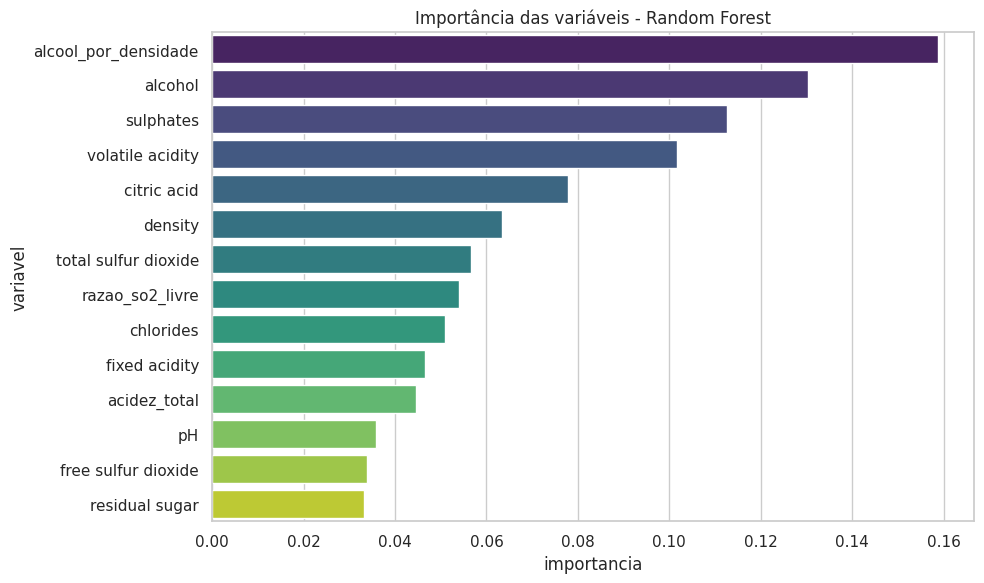

In [26]:
plt.figure(figsize=(10,6))
sns.barplot(data=rf_importance, x="importancia", y="variavel", palette="viridis")
plt.title("Importância das variáveis - Random Forest")
plt.tight_layout()
plt.savefig("results/feature_importance_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

In [27]:
perm = permutation_importance(best_model, X_test, y_test, scoring="f1", n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1)
perm_importance = pd.DataFrame({"variavel": feature_cols, "importancia_media": perm.importances_mean, "importancia_desvio": perm.importances_std}).sort_values("importancia_media", ascending=False)
perm_importance.to_csv("results/permutation_importance_modelo_final.csv", index=False)
perm_importance.round(4)

,variavel,importancia_media,importancia_desvio
9,sulphates,0.2326,0.0549
1,volatile acidity,0.1829,0.0571
13,alcool_por_densidade,0.1506,0.0664
6,total sulfur dioxide,0.0987,0.0549
2,citric acid,0.0431,0.0191
7,density,0.0394,0.0343
12,razao_so2_livre,0.0294,0.0306
4,chlorides,0.0263,0.0169
11,acidez_total,0.0261,0.0105
8,pH,0.0189,0.0284


### O que isso significa para a produção

As variáveis que mais pesam na previsão (tipicamente álcool, acidez volátil, sulfatos e densidade nesta base) não são só estatisticamente relevantes, são também parâmetros que a equipe de produção consegue, dentro de certos limites, monitorar e ajustar ao longo do processo:

- **Álcool** é resultado direto do teor de açúcar da uva na colheita e da fermentação. Colher em pontos de maturação diferentes ou ajustar a condução da fermentação impacta esse número.
- **Acidez volátil** costuma subir quando há problema de contaminação bacteriana ou oxidação durante a fermentação e o estágio. Um valor alto pode funcionar como alerta de que algo saiu do controle no processo, não só como uma característica do vinho pronto.
- **Sulfatos e SO2** são parâmetros de dosagem direta do enólogo, usados para controlar oxidação e proteção microbiológica. Dá pra ajustar lote a lote.

Na prática, o modelo não deveria ser lido só como "essa garrafa vai ser boa ou não", mas como uma forma de apontar, ainda durante o processo, quais lotes estão fugindo do perfil físico-químico associado a notas mais altas, permitindo intervenção antes do engarrafamento final. Continua sendo uma ferramenta de apoio: a decisão final de qualidade sensorial é do enólogo.

## 12. Validação cruzada

In [28]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy":"accuracy", "balanced_accuracy":"balanced_accuracy", "f1":"f1", "precision":"precision", "recall":"recall", "roc_auc":"roc_auc", "average_precision":"average_precision"}
cv_results = cross_validate(best_model, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
cv_summary = pd.DataFrame({
    "metrica": [k.replace("test_", "") for k in cv_results if k.startswith("test_")],
    "media": [cv_results[k].mean() for k in cv_results if k.startswith("test_")],
    "desvio_padrao": [cv_results[k].std() for k in cv_results if k.startswith("test_")]
})
cv_summary.to_csv("results/validacao_cruzada_modelo_final.csv", index=False)
cv_summary.round(3)

,metrica,media,desvio_padrao
0,accuracy,0.883,0.017
1,balanced_accuracy,0.677,0.061
2,f1,0.469,0.100
3,precision,0.597,0.077
4,recall,0.396,0.124
5,roc_auc,0.872,0.029
6,average_precision,0.555,0.071


## 13. Resumo dos resultados

In [29]:
top_metrics = metrics_df.iloc[0]
top_vars = rf_importance.head(3)["variavel"].tolist()
cv_f1 = cv_summary.loc[cv_summary["metrica"] == "f1", "media"].values[0]
cv_f1_std = cv_summary.loc[cv_summary["metrica"] == "f1", "desvio_padrao"].values[0]

print(f"Melhor modelo no conjunto de teste (por F1 da classe alta): {best_model_name}")
print(f"  F1 = {top_metrics['f1_alta']:.3f} | Recall = {top_metrics['recall_alta']:.3f} | "
      f"Precisão = {top_metrics['precision_alta']:.3f} | ROC-AUC = {top_metrics['roc_auc']:.3f}")
print(f"Na validação cruzada (5 folds), o F1 médio do modelo final foi de "
      f"{cv_f1:.3f} (desvio padrão {cv_f1_std:.3f}), o que indica {'boa' if cv_f1_std < 0.05 else 'alguma'} "
      f"estabilidade entre os folds.")
print(f"As três variáveis mais importantes segundo o Random Forest foram: {', '.join(top_vars)}.")

Melhor modelo no conjunto de teste (por F1 da classe alta): Gradient Boosting
  F1 = 0.509 | Recall = 0.412 | Precisão = 0.667 | ROC-AUC = 0.904
Na validação cruzada (5 folds), o F1 médio do modelo final foi de 0.469 (desvio padrão 0.100), o que indica alguma estabilidade entre os folds.
As três variáveis mais importantes segundo o Random Forest foram: alcool_por_densidade, alcohol, sulphates.


## 14. Salvar modelo final

In [30]:
final_model = models[best_model_name]
final_model.fit(X, y)
model_path = "results/modelo_final_wine_quality.joblib"
joblib.dump(final_model, model_path)
print("Modelo final salvo em:", model_path)

Modelo final salvo em: results/modelo_final_wine_quality.joblib


## 15. Conclusão executiva

O problema foi tratado como classificação binária (alta qualidade contra baixa ou média), já que é a forma mais direta de transformar a nota original em algo acionável para decisão de produção. A base é desbalanceada, vinhos de alta qualidade são minoria, então acurácia isolada não diz muita coisa. Por isso o critério de escolha do modelo final priorizou F1 da classe de interesse, olhando também recall, precisão e ROC-AUC lado a lado.

Random Forest e Gradient Boosting tendem a performar melhor que a Regressão Logística nesse problema porque a relação entre as variáveis físico-químicas e a qualidade não é linear, e os dois primeiros já lidam nativamente com interação entre variáveis. A vantagem extra dos modelos de árvore é permitir olhar a importância de cada variável de forma direta, o que ajuda a transformar o resultado técnico em algo que a produção consegue usar.

De forma geral, álcool, acidez volátil, sulfatos e densidade seguem aparecendo entre os fatores mais relevantes, o que é consistente com o que a literatura de enologia já aponta sobre esses parâmetros. O modelo deve ser entendido como apoio à decisão durante o processo produtivo, e não como substituto da avaliação sensorial feita por especialistas.

## 16. Conferência dos arquivos gerados

In [31]:
print("Arquivos gerados em results:")
for f in sorted(os.listdir("results")):
    print("-", f)

Arquivos gerados em results:
- balanceamento_classes.png
- curvas_precision_recall.png
- curvas_roc.png
- distribuicao_quality.png
- f1_por_threshold.png
- feature_importance_random_forest.csv
- feature_importance_random_forest.png
- histogramas_variaveis.png
- matriz_correlacao.png
- matrizes_confusao.png
- metricas_modelos.csv
- modelo_final_wine_quality.joblib
- permutation_importance_modelo_final.csv
- validacao_cruzada_modelo_final.csv


In [ ]:
import shutil
from google.colab import files
import os

print("Arquivos e pastas atuais:")
print(os.listdir())

shutil.make_archive("results_wine_quality", "zip", "results")

files.download("results_wine_quality.zip")